In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
"""
SECTION 1 -- Inputs and derivation of T_HOP (per-wafer pipeline depth cost)
============================================================================

T_HOP is the seconds added to EVERY generated token's latency (TPOT) per
wafer of pipeline depth. Nobody publishes it. We derive it from public
benchmarks two independent ways, then adopt the dense-pair value.
"""

# %% [cell 1: measured inputs, with sources] ---------------------------------
# All speeds are output tok/s/user. (C) = Cerebras-reported, (AA) = measured
# by Artificial Analysis. Wafer counts N are OUR estimates (see cell 2) --
# Cerebras does not publish deployment sizes or serving precision.

BENCHMARKS = {
    # name:                dict(tokps, layers, weights_GB, precision, source)
    "Llama 3.1 70B": dict(
        tokps=2100, layers=80, weights_gb=140, precision="16-bit",
        source="(C/AA) cerebras.ai/blog/cerebras-inference-3x-faster; "
               "businesswire.com/news/home/20241024856476/en"),
    "Llama 3.1 405B": dict(
        tokps=969, layers=126, weights_gb=810, precision="16-bit",
        source="(AA) cerebras.ai/blog/llama-405b-inference; "
               "businesswire.com/news/home/20241118828747/en"),
    "gpt-oss-120B": dict(
        tokps=2059, layers=36, weights_gb=63, precision="MXFP4 (native)",
        source="(AA, SemiAnalysis anchor) artificialanalysis.ai/providers/"
               "cerebras; cerebras.ai/blog/blackwell-vs-cerebras"),
    "GLM 4.7 355B": dict(
        tokps=1201, layers=92, weights_gb=355, precision="FP8 (assumed)",
        source="(AA, SemiAnalysis anchor) tokenomics.info/cerebras "
               "methodology; edenai.co/providers/cerebras"),
    "Kimi K2.6 1T": dict(
        tokps=981, layers=61, weights_gb=500, precision="4-bit (assumed)",
        source="(AA) Artificial Analysis Kimi K2.6 provider charts, "
               "10k input tokens; E2E 5.6 s for 500 output tokens"),
}

# Wafer capacity: 44 GB SRAM per WSE-3, ~15% reserved for activations,
# runtime, fragmentation -> ~37.4 GB usable for weights.
# Source for 44 GB: Cerebras WSE-3 datasheet / cerebras.ai product pages.
# The 15% overhead matches the tokenomics.info calculator convention.
USABLE_GB = 44 * 0.85

# %% [cell 2: estimate pipeline depth N per benchmark] ------------------------
import math

print(f"{'model':>16} {'tok/s':>6} {'TPOT us':>8} {'layers':>7} "
      f"{'weights':>8} {'est. N':>7}")
for name, b in BENCHMARKS.items():
    b["N"] = math.ceil(b["weights_gb"] / USABLE_GB)
    b["tpot_us"] = 1e6 / b["tokps"]
    print(f"{name:>16} {b['tokps']:6d} {b['tpot_us']:8.0f} "
          f"{b['layers']:7d} {b['weights_gb']:7d}G {b['N']:7d}")
# Cross-check: tokenomics.info calculator gives N=14 for Kimi K2.6 at
# 4-bit / low concurrency -- matches ceil(500/37.4)=14. Sanity holds.

# %% [cell 3: METHOD A -- dense pair (preferred)] -----------------------------
# Model: TPOT = a * layers + t_hop * N
#   a      = per-layer processing time (compute + on-wafer routing)
#   t_hop  = per-wafer transit cost (fabric latency, sync)
# Using the two DENSE Llama models: same family, same 16-bit precision,
# same vendor stack -- the cleanest controlled pair in public data.
# Two equations, two unknowns:
b70, b405 = BENCHMARKS["Llama 3.1 70B"], BENCHMARKS["Llama 3.1 405B"]
import numpy as np
A = np.array([[b70["layers"],  b70["N"]],
              [b405["layers"], b405["N"]]], dtype=float)
y = np.array([b70["tpot_us"], b405["tpot_us"]])
a_us, thop_us = np.linalg.solve(A, y)
print(f"METHOD A (dense pair):  a = {a_us:.1f} us/layer, "
      f"t_hop = {thop_us:.1f} us/wafer")
# -> t_hop ~= 18 us/wafer, a ~= 5.1 us/layer.
# Assumption: per-layer time is width-independent (405B layers = 70B layers
# in latency). Defensible if layer latency is traversal- not compute-bound;
# it is an assumption. Both speeds are vendor peaks, likely incl.
# speculative decoding -- differing acceptance rates would bias the pair.

# %% [cell 4: METHOD B -- cross-catalog fit (upper bound)] --------------------
# Ignore layers, fit TPOT = alpha + t_hop * N through the three MoE-era
# anchors (gpt-oss-120B, GLM 4.7, Kimi K2.6). Confounded: the three models
# differ in layers, active params, architecture -- everything correlated
# with N gets absorbed into the slope, so this OVERSTATES t_hop.
tri = [BENCHMARKS[k] for k in ("gpt-oss-120B", "GLM 4.7 355B", "Kimi K2.6 1T")]
thop_b, alpha_b = np.polyfit([b["N"] for b in tri],
                             [b["tpot_us"] for b in tri], 1)
print(f"METHOD B (3-pt catalog): alpha = {alpha_b:.0f} us, "
      f"t_hop = {thop_b:.1f} us/wafer  (upper bound)")
# -> t_hop ~= 44 us/wafer. Also: if Kimi K2.6 is actually served FP8
# (N=27 not 14), this fit drops to ~20 us -- converging on Method A.

# %% [cell 5: adopted value + full input set for Sections 2-3] ----------------
T_HOP = round(thop_us) * 1e-6     # 18e-6 s -- Method A; range 18-44e-6
print(f"\nADOPTED: T_HOP = {T_HOP*1e6:.0f} us/wafer "
      f"(dense-pair derived; cross-catalog upper bound {thop_b:.0f} us)")

# Remaining inputs used by Sections 2 and 3:
ISL, OSL  = 10_000, 500   # AA benchmark workload (10k in / 500 out)
ACTIVE    = 32e9          # Kimi K2.6 active params/token (model card)
N0, I0    = 14, 981.0     # anchor: 981 tok/s at est. depth 14 (AA + calc)
T_E2E     = 5.6           # s, measured end-to-end at N0 (AA)
T_FIXED   = 0.2           # s, non-scaling overhead -- ASSUMPTION (0..2 s)
T_PRE0    = T_E2E - OSL / I0 - T_FIXED   # scalable prefill at N0
PF_DENSE  = 15.6e15       # dense FP16/wafer = 125 PF marketing / 8:1
                          # sparsity ("Feldman's Formula", SemiAnalysis:
                          # newsletter.semianalysis.com/p/cerebras-faster-
                          # tokens-please)
MFU, UTIL = 0.50, 1.0     # efficiency assumptions (soft +/-30% / ceiling)
KW_SYS = 23    # kW/system (TCO-table class) and datacenter PUE
N_OF_C = {16: 14, 32: 14, 64: 15, 128: 16, 256: 18, 512: 23,
          1024: 32, 2048: 51, 4096: 89, 8192: 163}
          # systems per concurrency: tokenomics.info/cerebras sweep
          # (Kimi K2.6, 4-bit W, 16-bit KV, 256k max ctx, 10k ISL, 15% ovh)
print(f"T_PRE0 = {T_PRE0:.2f} s at N0={N0}")

           model  tok/s  TPOT us  layers  weights  est. N
   Llama 3.1 70B   2100      476      80     140G       4
  Llama 3.1 405B    969     1032     126     810G      22
    gpt-oss-120B   2059      486      36      63G       2
    GLM 4.7 355B   1201      833      92     355G      10
    Kimi K2.6 1T    981     1019      61     500G      14
METHOD A (dense pair):  a = 5.1 us/layer, t_hop = 18.0 us/wafer
METHOD B (3-pt catalog): alpha = 395 us, t_hop = 44.3 us/wafer  (upper bound)

ADOPTED: T_HOP = 18 us/wafer (dense-pair derived; cross-catalog upper bound 44 us)
T_PRE0 = 4.89 s at N0=14


In [3]:
"""
Slot-limited vs compute-limited request rates for Cerebras WSE-3 serving
Kimi K2.6, across concurrency buckets -- v3: adds derived INTERACTIVITY
(decode tok/s/user) per row.

Table: Concurrency | Systems N | Prefill s | Decode s | T_req s |
Interactivity tok/s/user | Slot lambda | Compute lambda | Binding | Out tok/s.

=============================== INPUTS ======================================
Measured (Artificial Analysis, Kimi K2.6):
  Baseline 5.6 s end-to-end for 10k in / 500 out at depth N0 ~= 14 wafers,
  decoding at I0 = 981 tok/s/user. Single-probe measurement at unknown
  (likely light) load -- all lambdas are best-case ceilings.

Calculator sweep (tokenomics.info/cerebras, Kimi K2.6: 1T total / 32B active,
61 layers, 4-bit weights = 500 GB, 16-bit KV, 256k max ctx, 10k ISL,
15% overhead): N_OF_C = systems needed for C concurrent requests.

Constants: ACTIVE = 32e9; ISL, OSL = 10_000, 500.
Assumptions (edit to stress): PF_DENSE = 15.6e15 dense FP16/wafer
("Feldman's Formula" derate of the 125 PF marketing peak); MFU = 0.50;
UTIL = 1.0 (pure ceiling).

============================ T_REQ(N) MODEL =================================
decode(N)  = OSL * TPOT(N),  TPOT(N) = 1/I0 + max(0, N-N0)*T_HOP   -- grows
             (serial loop: each token's activations traverse all N wafers;
              T_HOP = 44.3 us/wafer, least-squares on published speeds:
              gpt-oss-120B 2,059 t/s @ N~2, GLM 4.7 1,201 @ N~10,
              Kimi K2.6 981 @ N~14; ~20 us lower bound if K2.6 is FP8)
prefill(N) = T_PRE0 * N0 / N                                        -- shrinks
             (parallel work, chunk-pipelined across all wafers)
T_FIXED    = 1.0 s non-scaling overhead (ASSUMPTION, 0..2 s plausible)
T_PRE0     = 5.6 - OSL/I0 - T_FIXED  (~4.09 s at N0)
t_req(N)   = T_FIXED + prefill(N) + decode(N)

INTERACTIVITY(N) = 1 / TPOT(N) -- the per-user decode speed at depth N.
This is what the user FEELS while tokens stream; it decays monotonically
with N even where total T_req improves, because T_req gains come from
prefill, not decode.

============================== RATE FORMULAS ================================
F = 2 * ACTIVE * (ISL + OSL)                      [2 FLOP/param/token]
lambda_slot = C / t_req(N) * UTIL                 [Little's Law]
lambda_cap  = N * PF_DENSE * MFU * UTIL / F
Binding = min of the two. Not modeled: queueing near the compute bound;
contention stretching the measured baseline at high occupancy.
"""

# ------------------------------- inputs ------------------------------------
ISL, OSL = 10_000, 500
ACTIVE   = 32e9 # Active parameters per token
PF_DENSE = 15.6e15 # Dense FP16 compute per wafer
MFU      = 0.50
UTIL     = 1.0

N0, I0  = 14, 981.0 # at pipeline depth N0 = 14 wafers (the calculator's system count for K2.6 at 4-bit weights), Artificial Analysis measured I0 = 981 tok/s/user decode.
T_HOP   = 18e-6 # Depth tax: seconds added to EVERY token's generation time per wafer of pipeline beyond N0.
T_FIXED = 0.2
T_PRE0  = 5.6 - OSL / I0 - T_FIXED

N_OF_C = {16: 14, 32: 14, 64: 15, 128: 16, 256: 18, 512: 23,
          1024: 32, 2048: 51, 4096: 89, 8192: 163}


def row_metrics(N):
    """(prefill_s, decode_s, t_req_s, interactivity_tok_s) at depth N."""
    tpot    = 1.0 / I0 + max(0, N - N0) * T_HOP
    decode  = OSL * tpot
    prefill = T_PRE0 * N0 / N
    return prefill, decode, T_FIXED + prefill + decode, 1.0 / tpot


F = 2 * ACTIVE * (ISL + OSL)

rows = []
for C, N in N_OF_C.items():
    pre, dec, tr, inter = row_metrics(N)
    lam_slot = C / tr * UTIL
    lam_cap  = N * PF_DENSE * MFU * UTIL / F
    lam      = min(lam_slot, lam_cap)
    binding  = "slots" if lam_slot < lam_cap else "compute"
    if binding == "slots" and lam_cap / lam_slot < 1.10:
        binding = "slots (barely)"
    rows.append((C, N, pre, dec, tr, inter, lam_slot, lam_cap, binding, lam))

print(f"FLOPs/request: {F:.3g} | T_FIXED={T_FIXED}s  "
      f"T_HOP={T_HOP*1e6:.1f}us/wafer  T_PRE0={T_PRE0:.2f}s @ N0={N0}")
print(f"{'Concurr.':>8} {'Sys N':>6} {'Prefill s':>9} {'Decode s':>8} "
      f"{'T_req s':>8} {'Interact.':>9} {'Slot lam':>9} {'Comp lam':>9} "
      f"{'Binding':>15} {'Out tok/s':>10}")
for C, N, pre, dec, tr, inter, ls, lc, b, lam in rows:
    print(f"{C:8d} {N:6d} {pre:9.2f} {dec:8.2f} {tr:8.2f} {inter:9.0f} "
          f"{ls:9.1f} {lc:9.0f} {b:>15} {lam*OSL:10,.0f}")

FLOPs/request: 6.72e+14 | T_FIXED=0.2s  T_HOP=18.0us/wafer  T_PRE0=4.89s @ N0=14
Concurr.  Sys N Prefill s Decode s  T_req s Interact.  Slot lam  Comp lam         Binding  Out tok/s
      16     14      4.89     0.51     5.60       981       2.9       162           slots      1,429
      32     14      4.89     0.51     5.60       981       5.7       162           slots      2,857
      64     15      4.56     0.52     5.28       964      12.1       174           slots      6,057
     128     16      4.28     0.53     5.01       948      25.6       186           slots     12,783
     256     18      3.80     0.55     4.55       916      56.3       209           slots     28,136
     512     23      2.98     0.59     3.77       846     135.9       267           slots     67,951
    1024     32      2.14     0.67     3.01       744     340.1       371  slots (barely)    170,032
    2048     51      1.34     0.84     2.39       593     858.7       592         compute    295,982
    4096  

Loaded 160 rows from /Users/nicolasmuller/Desktop/Architecture First Pass /InferenceX_Kimi-K2.5_interactivity.csv


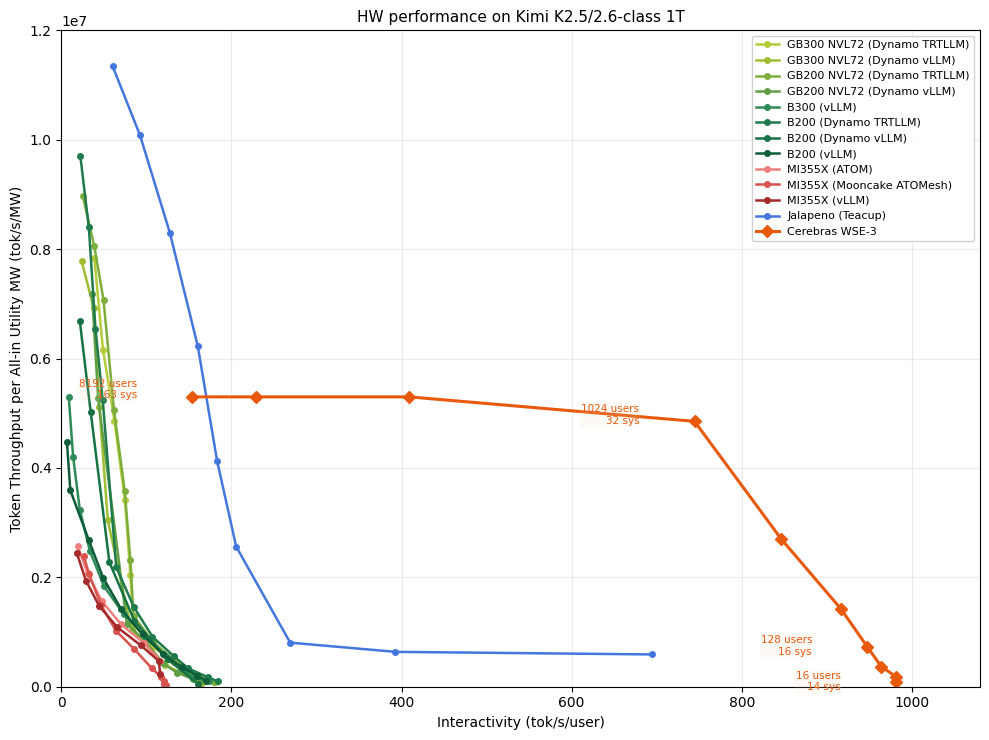


     C     N  tok/s/user   tok/s/MW
    16    14         981      0.09M
    32    14         981      0.19M
    64    15         964      0.37M
   128    16         948      0.73M
   256    18         916      1.43M
   512    23         846      2.70M
  1024    32         744      4.85M
  2048    51         409      5.30M
  4096    89         229      5.30M
  8192   163         154      5.30M


In [4]:
"""
Token Throughput per All-in Utility MW vs Interactivity -- Kimi K2.5/2.6-class
1T MoE, 10k in / 500 out workload.

GPU / Jalapeno curves: measured InferenceX CSV (Pareto "Optimal Only").

CEREBRAS v5 -- fed by the slot/compute table model (v3 table code):
  * T_HOP  = 18 us/wafer, DENSE-PAIR DERIVED: solving
      TPOT = a*layers + t_hop*N  on Llama 3.1 70B (2,100 t/s, 80 layers,
      N~4 @16-bit) and Llama 3.1 405B (969 t/s, 126 layers, N~22 @16-bit)
      gives t_hop ~= 18 us, a ~= 5.1 us/layer. Cross-catalog 3-point fit
      gave 44 us; treat 18-44 us as the honest range (edit T_HOP to stress).
  * T_req(N) is now depth-dependent and NON-MONOTONIC:
      decode(N)  = OSL * TPOT(N),  TPOT(N) = 1/I0 + max(0,N-N0)*T_HOP  (grows)
      prefill(N) = T_PRE0 * N0/N   (parallel, chunk-pipelined -> shrinks)
      T_FIXED    = 0.2 s non-scaling overhead (ASSUMPTION, 0..2 s)
      T_PRE0     = 5.6 - OSL/I0 - T_FIXED   (defined at N0)
  * Anchor: I0 = 981 tok/s/user at N0 = 14 wafers (Artificial Analysis,
    Kimi K2.6, 10k input; 5.6 s measured E2E). N0 assumes 4-bit serving;
    if FP8, N0 ~= 27 and the curve shifts.
  * Compute ceiling: N x 15.6 PF dense FP16 ("Feldman derate" of 125 PF
    marketing) x MFU 0.50; UTIL = 1.0 (pure ceiling, matches table code).
  * Power: KW_SYS = 23 kW/system x PUE 1.15 for the per-MW axis.

Fleet sizes per concurrency from the tokenomics.info calculator sweep
(Kimi K2.6, 4-bit W / 16-bit KV, 256k max ctx, 10k ISL, 15% overhead).

Runs locally: CSV searched in cwd, ~/Desktop/WIP, ~/Downloads; PNG saved
next to the CSV (falls back to cwd, then home).
"""

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------- locate the CSV --------------------------------
CSV_NAME = 'InferenceX_Kimi-K2.5_interactivity.csv'   # dot version (local file)
candidates = [Path.cwd() / CSV_NAME,
              Path.home() / 'Desktop' / 'WIP' / CSV_NAME,
              Path.home() / 'Downloads' / CSV_NAME]
csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        f"{CSV_NAME} not found. Looked in:\n"
        + "\n".join(f"  {p}" for p in candidates)
        + "\nMove the CSV next to this notebook or edit `candidates`.")

df = pd.read_csv(csv_path, comment='#')
print(f"Loaded {len(df)} rows from {csv_path}")

YCOL = 'Token Throughput per All in Utility MW (tok/s/MW)'
XCOL = 'Interactivity (tok/s/user)'

STYLES = {
    'gb300_dynamo-trt':     ('GB300 NVL72 (Dynamo TRTLLM)', '#b5cc3a'),
    'gb300_dynamo-vllm':    ('GB300 NVL72 (Dynamo vLLM)',   '#9ebf34'),
    'gb200_dynamo-trt':     ('GB200 NVL72 (Dynamo TRTLLM)', '#7dae3c'),
    'gb200_dynamo-vllm':    ('GB200 NVL72 (Dynamo vLLM)',   '#5f9e44'),
    'b300_vllm':            ('B300 (vLLM)',                 '#2e8b57'),
    'b200_dynamo-trt':      ('B200 (Dynamo TRTLLM)',        '#1f7a4d'),
    'b200_dynamo-vllm':     ('B200 (Dynamo vLLM)',          '#177245'),
    'b200_vllm':            ('B200 (vLLM)',                 '#0e5c3a'),
    'mi355x_atom':          ('MI355X (ATOM)',               '#f08080'),
    'mi355x_mooncake-atom': ('MI355X (Mooncake ATOMesh)',   '#d9534f'),
    'mi355x_vllm':          ('MI355X (vLLM)',               '#a52a2a'),
    'jalapeno_teacup':      ('Jalapeno (Teacup)',           '#4477dd'),
}


def pareto(sub):
    """'Optimal Only': keep points not dominated in (interactivity, tok/s/MW)."""
    pts = sub[[XCOL, YCOL]].dropna().sort_values(XCOL, ascending=False).values
    best, keep = -np.inf, []
    for x, y in pts:
        if y > best:
            keep.append((x, y)); best = y
    return np.array(keep[::-1])


plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 7.5), facecolor="white")
ax.set_facecolor("white")

for key, (label, color) in STYLES.items():
    sub = df[df['Hardware Key'] == key]
    if sub.empty:
        continue
    f = pareto(sub)
    ax.plot(f[:, 0], f[:, 1], '-o', color=color, ms=4, lw=1.8, label=label)

# ------------- Cerebras v5: table-model T_req(N), dense-pair T_HOP ----------
N_OF_C = {16: 14, 32: 14, 64: 15, 128: 16, 256: 18, 512: 23,
          1024: 32, 2048: 51, 4096: 89, 8192: 163}    # calculator sweep

ISL, OSL, TOK_REQ = 10_000, 500, 10_500
ACTIVE   = 32e9            # Kimi K2.6 active params/token
PF_DENSE = 15.6e15         # dense FP16 per wafer (Feldman derate)
MFU      = 0.50            # matches table code
UTIL     = 1.0             # pure ceiling, matches table code

N0, I0   = 14, 981.0       # measured anchor (AA) at 4-bit depth estimate
T_HOP    = 18e-6           # dense-pair derived (range 18-44e-6)
T_FIXED  = 0.2             # s, non-scaling overhead (ASSUMPTION)
T_PRE0   = 5.6 - OSL / I0 - T_FIXED   # scalable prefill at N0 (~4.89 s)

KW_SYS = 23     # kW/system, datacenter PUE -> per-MW axis

F = 2 * ACTIVE * TOK_REQ   # FLOPs per request

xs, ys, notes = [], [], []
for C, N in N_OF_C.items():
    tpot    = 1.0 / I0 + max(0, N - N0) * T_HOP     # depth penalty (grows)
    inter   = 1.0 / tpot                             # tok/s/user at depth N
    prefill = T_PRE0 * N0 / N                        # pipelined (shrinks)
    t_req   = T_FIXED + prefill + OSL / inter        # non-monotonic residency
    lam_slot = C / t_req * UTIL                      # Little's Law, no queueing
    lam_cap  = N * PF_DENSE * MFU * UTIL / F         # FLOP ceiling
    lam      = min(lam_slot, lam_cap)
    inter    = inter * lam / lam_slot                # bends more if capped
    mw = N * KW_SYS / 1000
    xs.append(inter)
    ys.append(lam * TOK_REQ / mw)
    notes.append((C, N))

ax.plot(xs, ys, '-D', color='#e8590c', ms=6, lw=2.2, label='Cerebras WSE-3')
for (C, N), x, y in list(zip(notes, xs, ys))[::3]:
    ax.annotate(f'{C} users\n{N} sys', xy=(x, y),
                xytext=(max(x - 65, 40), y * 1.025),
                fontsize=7.5, color='#e8590c', va='center', ha='right',
                bbox=dict(boxstyle="round,pad=0.12", fc='wheat',
                          alpha=0.12, lw=0))

ax.set_xlabel('Interactivity (tok/s/user)')
ax.set_ylabel('Token Throughput per All-in Utility MW (tok/s/MW)')
ax.set_title('HW performance on Kimi K2.5/2.6-class 1T', fontsize=11)
ax.set_xlim(0, 1080)
ax.set_ylim(0, 12e6)
ax.grid(alpha=0.25)
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
fig.tight_layout()

plt.show()

print(f"\n{'C':>6} {'N':>5} {'tok/s/user':>11} {'tok/s/MW':>10}")
for (C, N), x, y in zip(notes, xs, ys):
    print(f"{C:6d} {N:5d} {x:11.0f} {y/1e6:9.2f}M")

compute-ideal prefill : (1024, 35, 848.0414759156113, 1.4137568393945312, 28.63015709881075, 79591.83673469389)
measured prefill      : (1024, 35, 848.0414759156113, 20.985867608625302, 28.63015709881075, 79591.83673469389)
Cerebras selling $34.43/hr, measured-prefill: C=1024, N=35, 848 tok/s/user, t_req=21.0s, 79,592 tok/s/wafer -> $0.120/M tok
Cerebras selling $34.43/hr, ideal-prefill: C=1024, N=35, 848 tok/s/user, t_req=1.4s, 79,592 tok/s/wafer -> $0.120/M tok
Cerebras BOM $27.81/hr, measured-prefill: C=1024, N=35, 848 tok/s/user, t_req=21.0s, 79,592 tok/s/wafer -> $0.097/M tok
Cerebras BOM $27.81/hr, ideal-prefill: C=1024, N=35, 848 tok/s/user, t_req=1.4s, 79,592 tok/s/wafer -> $0.097/M tok


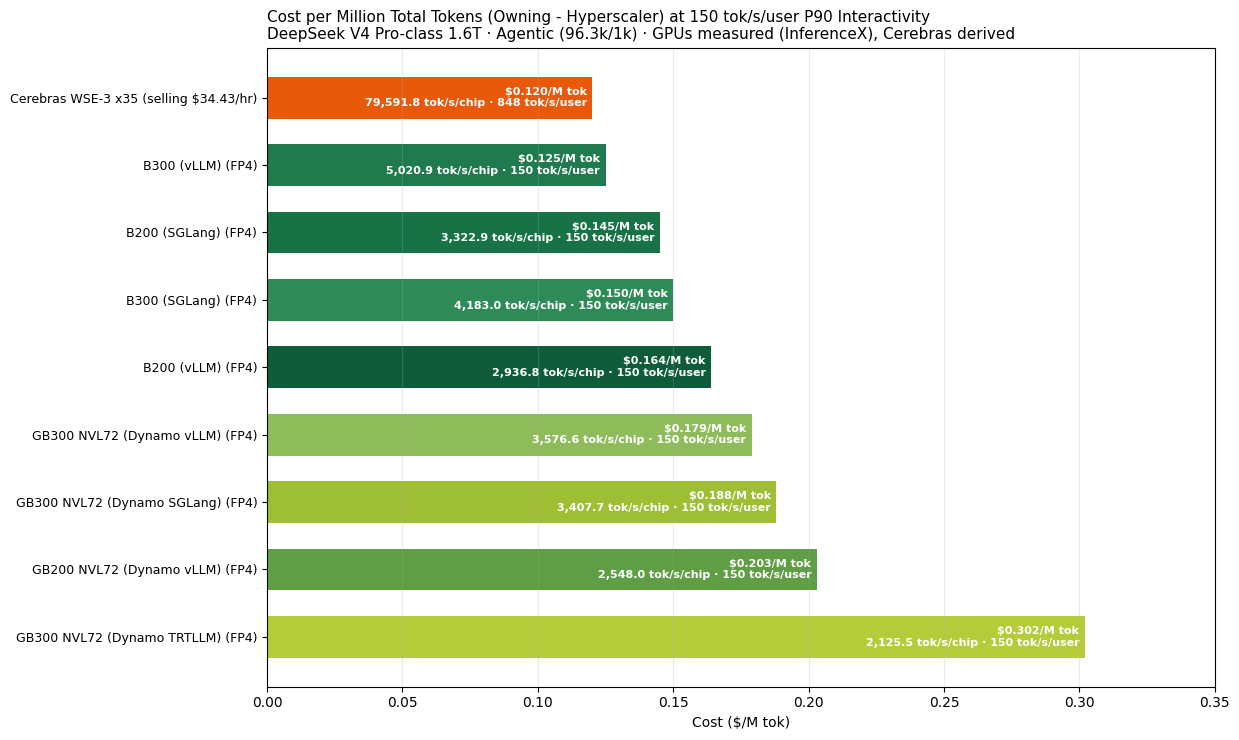

In [5]:
"""
Cost per Million TOTAL Tokens (Owning - Hyperscaler) at 150 tok/s/user P90
interactivity -- DeepSeek V4 Pro-class agentic workload -- InferenceX style,
WITH a derived Cerebras WSE-3 bar added.

============================ GPU BARS (measured) ============================
Transcribed verbatim from the SemiAnalysis InferenceX chart (updated
2026-09-01, "Agentic" scenario, FP4/FP8, 150 tok/s/user P90 target):
each bar = ($/M total tok, total tok/s/chip). Their formula:
    $/M tok = TCO $/chip/hr / (tok/s/chip * 3600 / 1e6)
Sanity check (B300 vLLM): 2.26 / (5020.9*3600/1e6) = $0.125/M  -- matches.

========================= CEREBRAS BAR (derived) ============================
Reasoning chain, every step named:

1. WORKLOAD. InferenceX "Agentic" for DeepSeek V4 Pro is a long-context mix.
   We approximate it with the SemiAnalysis-measured agentic P50: ISL=96.3k,
   and OSL=1k (their 8K/1K-style output scale). Total 97.3k tok/request.
   This is the chart's biggest apples-to-apples caveat: their mix is a
   distribution; we use a point estimate.

2. MODEL ON WAFERS. Cerebras does not serve DeepSeek V4 Pro (1.6T/49B
   active); we model the hypothetical: 4-bit weights = 800 GB. KV: 10 kB/tok
   FP16 (model card) -> halved to 5 kB at 8-bit KV. Concurrency chosen below.

3. INTERACTIVITY TARGET. The chart fixes 150 tok/s/user; GPUs must batch
   down to hit it. Cerebras' problem is inverted: it must not let pipeline
   DEPTH push it below 150. TPOT(N) = TPOT_base + (N-N0)*T_HOP with
   T_HOP = 18 us/wafer (dense-pair derived, Section 1; 44 us upper bound).
   TPOT_base for a 49B-active model ~ 1/779 s (SemiAnalysis interactivity
   fit 3322/49^0.294, tokenomics.info methodology) at its weight-only depth
   N0 = ceil(800/37.4) = 22 wafers.
   Depth budget to stay >=150 tok/s: TPOT <= 6.67 ms -> N <= 22 +
   (6.67ms - 1.28ms)/18us ~= 320 wafers. Depth is NOT the binder here;
   150 tok/s is a low bar for a wafer. It will bind through KV instead.

4. FLEET SIZING. Choose concurrency C so the fleet is compute-balanced
   (slot rate ~ compute cap), then N = ceil((weights + C*KV_per_req)/37.4).
   Solved iteratively below.

5. COST. Same convention as the chart's TCO chips: $34.43/wafer/hr at
   selling price (SemiAnalysis AI Cloud TCO Model, WSE-3 column), which is
   the "Owning - Hyperscaler" analog. BOM variant $27.81 shown too.

6. OUTPUT METRIC. $/M TOTAL tokens and total tok/s/wafer, matching axes.
   NOTE: at 96.3k ISL, total-token metrics flatter everyone (Cerebras
   included); mind cache-read pricing when converting to revenue.

Honest caveats: Cerebras bar is a model, GPU bars are measurements; the
prefill MFU, T_HOP, and 4-bit serving are assumptions; no prefix caching
is modeled (it would improve Cerebras materially on agentic traffic).
"""

import numpy as np
import matplotlib.pyplot as plt

# ------------------- measured GPU bars (InferenceX, verbatim) ---------------
GPU_BARS = [  # (label, $/M total tok, total tok/s/chip, color)
    ("B300 (vLLM) (FP4)",                0.125, 5020.9, "#1f7a4d"),
    ("B200 (SGLang) (FP4)",              0.145, 3322.9, "#177245"),
    ("B300 (SGLang) (FP4)",              0.150, 4183.0, "#2e8b57"),
    ("B200 (vLLM) (FP4)",                0.164, 2936.8, "#0e5c3a"),
    ("GB300 NVL72 (Dynamo vLLM) (FP4)",  0.179, 3576.6, "#8fbc5a"),
    ("GB300 NVL72 (Dynamo SGLang) (FP4)",0.188, 3407.7, "#9ebf34"),
    ("GB200 NVL72 (Dynamo vLLM) (FP4)",  0.203, 2548.0, "#5f9e44"),
    ("GB300 NVL72 (Dynamo TRTLLM) (FP4)",0.302, 2125.5, "#b5cc3a"),
]

# ------------------------- Cerebras derivation ------------------------------
# Step 1: workload
ISL, OSL = 96_300, 1_000
TOK_REQ  = ISL + OSL

# Step 2: model on wafers
WEIGHTS_GB   = 800.0                  # 1.6T @ 4-bit
KV_GB_PT     = 5e-6                   # GB per token @ 8-bit KV (10kB FP16 / 2)
USABLE_GB    = 44 * 0.85              # per-wafer SRAM after 15% overhead
ACTIVE       = 49e9

# Step 3: interactivity at depth
T_HOP   = 18e-6                       # s/wafer (Section 1, dense pair)
N0      = int(np.ceil(WEIGHTS_GB / USABLE_GB))          # 22 weight-only depth
TPOT0   = 1 / (3322 / 49**0.294)      # base TPOT, SemiAnalysis fit -> 1/779 s
def interactivity(N): return 1 / (TPOT0 + max(0, N - N0) * T_HOP)

# Step 4: size fleet so slots ~ compute (balanced), iterate C -> N -> rates
PF_DENSE, MFU, UTIL = 15.6e15, 0.50, 1.0
T_FIXED = 0.2
F       = 2 * ACTIVE * TOK_REQ               # FLOPs per request

# Two prefill models bracket reality:
#  (a) compute-ideal: 2*ACTIVE*ISL / (N*PF_DENSE*MFU)  -- roofline, optimistic
#  (b) measured-throughput: Kimi K2.6 showed 0.509 ms per input token at
#      N=14 wafers (5.09 s / 10k, AA). Scale ~1/N: SEC_PER_TOK0 * 14 / N.
#      This embeds all real-world prefill inefficiency -- conservative.
SEC_PER_TOK0, N_MEAS = 0.509e-3, 14

def size_fleet(prefill_model):
    for C in [256, 512, 1024, 2048, 4096, 8192]:
        N = int(np.ceil((WEIGHTS_GB + C * ISL * KV_GB_PT) / USABLE_GB))
        inter = interactivity(N)
        if prefill_model == "ideal":
            prefill = 2*ACTIVE*ISL / (N*PF_DENSE*MFU)
        else:
            prefill = ISL * SEC_PER_TOK0 * N_MEAS / N
        t_req = T_FIXED + prefill + OSL / inter
        lam   = min(C / t_req, N * PF_DENSE * MFU / F) * UTIL
        if inter >= 150 and lam >= 0.90 * min(C/t_req, N*PF_DENSE*MFU/F):
            yield (C, N, inter, t_req, lam, lam * TOK_REQ / N)

# pick, for each model, the C that maximizes tok/s/wafer (best economics)
ideal = max(size_fleet("ideal"),    key=lambda r: r[5])
meas  = max(size_fleet("measured"), key=lambda r: r[5])
print("compute-ideal prefill :", ideal)
print("measured prefill      :", meas)
C, N, inter, t_req, lam, tokps_w = meas   # CONSERVATIVE variant plotted
for price_hr, tag in [(34.43, "selling"), (27.81, "BOM")]:
    for label, r in [("measured-prefill", meas), ("ideal-prefill", ideal)]:
        cost = price_hr / (r[5] * 3600 / 1e6)
        print(f"Cerebras {tag} ${price_hr}/hr, {label}: C={r[0]}, N={r[1]}, "
              f"{r[2]:.0f} tok/s/user, t_req={r[3]:.1f}s, "
              f"{r[5]:,.0f} tok/s/wafer -> ${cost:.3f}/M tok")

COST_SELL = 34.43 / (tokps_w * 3600 / 1e6)
COST_BOM  = 27.81 / (tokps_w * 3600 / 1e6)

# ------------------------------- plot ---------------------------------------
# GPU bars run at the 150 tok/s/user P90 target (InferenceX config);
# the Cerebras deployment delivers `inter` tok/s/user at the same cost point.
bars = [(lbl, c, t, col, 150) for (lbl, c, t, col) in GPU_BARS] + [
    (f"Cerebras WSE-3 x{N} (selling $34.43/hr)", COST_SELL, tokps_w,
     "#e8590c", inter),
]
bars.sort(key=lambda b: b[1])

fig, ax = plt.subplots(figsize=(12.5, 7.5), facecolor="white")
ax.set_facecolor("white")
for i, (label, cost, tps, color, ia) in enumerate(bars):
    ax.barh(i, cost, color=color, height=0.62)
    ax.text(cost - 0.002, i,
            f"${cost:.3f}/M tok\n{tps:,.1f} tok/s/chip · {ia:,.0f} tok/s/user",
            va="center", ha="right", fontsize=8, color="white",
            fontweight="bold")
ax.set_yticks(range(len(bars)), [b[0] for b in bars], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Cost ($/M tok)")
ax.set_title("Cost per Million Total Tokens (Owning - Hyperscaler) at "
             "150 tok/s/user P90 Interactivity\nDeepSeek V4 Pro-class 1.6T · "
             "Agentic (96.3k/1k) · GPUs measured (InferenceX), Cerebras derived",
             fontsize=11, loc="left")
ax.set_xlim(0, 0.35)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()

    ISL       C     N  tok/s/user   tok/s/MW
   1000      16    14        1021      0.05M
   1000      32    14        1021      0.11M
   1000      64    14        1021      0.22M
   1000     128    14        1021      0.44M
   1000     256    14        1021      0.88M
   1000     512    15        1002      1.68M
   1000    1024    16         984      3.20M
   1000    1544    17         967      4.60M
  10000      16    14         981      0.08M
  10000      32    14         981      0.16M
  10000      64    15         964      0.32M
  10000     128    16         948      0.63M
  10000     256    19         901      1.23M
  10000     512    23         846      2.35M
  10000    1024    33         735      4.17M
  10000    1147    35         716      4.56M
 100000      16    17         681      0.09M
 100000      32    20         656      0.17M
 100000      64    26         613      0.34M
 100000     128    38         541      0.67M
 100000     256    62         439      1.27M
 100000   

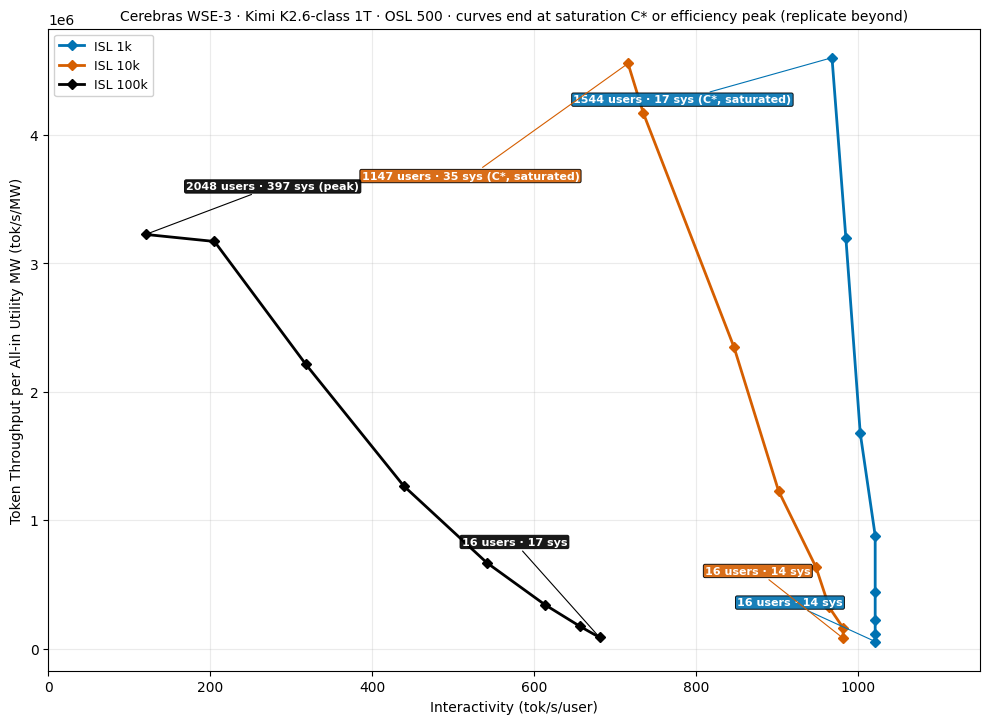

In [9]:
"""
Cerebras WSE-3 only: Token Throughput per All-in Utility MW vs Interactivity,
Kimi K2.6-class 1T MoE -- ONE CURVE PER INPUT LENGTH (ISL = 1k / 10k / 100k),
OSL = 500 fixed.

v3 corrections (model mechanics; the (1)-(4) derivations below are unchanged):

  a) Compute-saturated points TRUNCATED, not rescaled. v2 kept capped points
     via inter *= lam/lam_slot with a stale t_req: self-inconsistent, and
     every capped point sits at the identical per-wafer efficiency ceiling
     with worse interactivity -- strictly dominated by the saturation config.
     Each curve now ends at the bisected C* (annotated); beyond C* you
     replicate the C* unit, you don't deepen one pipeline.

  b) Pareto pruning past the efficiency peak. At ISL 100k the fleet never
     compute-saturates (cap grows with N faster than admitted load) but
     tok/s/MW rolls over while interactivity keeps falling: both axes worsen
     together, so post-peak concurrencies are dominated and are dropped.

  c) Quadratic attention FLOPs added to the COMPUTE CAP only:
     F = (2*ACTIVE + ATT_COEF*(ISL+OSL)/2) * (ISL+OSL), with ATT_COEF
     ~ 1.4e5 FLOPs/tok/ctx-tok (MLA 576-dim latent x 61 layers). ~11% cap
     reduction at 100k, negligible at 1k. Prefill stays LINEAR in ISL per
     the measured AA TTFT data in (2) (0.5 s @10k -> 2.6-5.2 s @100k is
     consistent with linear, not quadratic, at these lengths).

  d) KV stays 70 kB/tok 16-bit as derived in (3) -- canonical for this
     artifact. If serving with FP8 KV, set KV_GB_PT = 35e-6; fleets at
     100k shrink ~2x and the 100k curve shifts up and right. Keep this
     constant aligned with any companion chart before both ship.

================= DERIVING ISL-DEPENDENCE FROM MEASURED DATA ================

(1) DECODE SPEED vs ISL -- additive model, fitted on AA "Output Speed by
    Prompt Type" (Cerebras endpoints, median P50, tok/s at 1k/10k/100k):
        gpt-oss-120b (high) : 1818 / 1643 / 1157
        gpt-oss-120b (low)  : 1766 / 1633 /  886
        Gemma 4 31B         : 1431 / 1386 /  893
        Gemma 4 31B (NR)    : 1310 / 1267 /  824
        Llama 3.1 405B      :  969 (1k) -> 539 (100k)   [Cerebras blog]

    WHY ADDITIVE, NOT RATIOS: per-token time has two additive parts --
    weights/compute (ISL-independent) and KV-cache reads (linear in
    context). A multiplicative ratio wrongly scales both, so it transfers
    poorly between models of different base speed. Converting the table to
    TPOT (us) and fitting TPOT(ISL) = TPOT0 + BETA*ISL per model:
        gpt-oss (high): 550/609/864   -> BETA ~ 3.2 ns/ctx-token
        gpt-oss (low) : 566/612/1129  -> BETA ~ 5.7
        Gemma 4 31B   : 699/722/1120  -> BETA ~ 4.3
        Gemma 4 (NR)  : 763/789/1214  -> BETA ~ 4.6
        Llama 405B    : 1032 -> 1855  -> BETA ~ 8.3 (bigger KV/token: dense,
                                          126 layers, 16-bit -- consistent
                                          with BETA tracking KV bytes/token)
    ADOPTED: BETA = 4.4 ns/ctx-token (mean of the four AA models; band
    3.2-5.7). Anchored EXACTLY at Kimi's measured point (981 tok/s @ 10k):
        TPOT0 = 1/981 - BETA*10k = 975 us
    ->  I0(1k) = 1021,  I0(10k) = 981 (exact),  I0(100k) = 707 (band 647-772)
    CAVEAT: Kimi K2 uses MLA-compressed attention (smaller KV reads/token
    than the fitted models), so BETA=4.4 likely OVERSTATES its context tax;
    the 100k curve is, if anything, conservative-low on interactivity.

(2) PREFILL vs ISL -- AA "Latency by Prompt Type" (Cerebras): TTFT ~0.2-0.3 s
    @1k, 0.5 s @10k, 2.6-5.2 s @100k -- roughly linear in ISL. Convention:
    scalable prefill T_PRE(ISL, N) = T_PRE0_10K * (ISL/10k) * (N0/N),
    anchored at Kimi's 10k residency decomposition (5.6 - 0.51 - 0.2 =
    4.89 s at N0=14). NOTE: 4.89 s >> small-model TTFT at 10k; for a
    reasoning model part of it is likely 'thinking' tokens -- we treat it
    as slot residency, which is what the economics care about.

(3) FLEET SIZE vs ISL -- KV per token backed out of the tokenomics.info
    calculator screenshots: 717 GB at C=1024 / ISL=10k / 16-bit KV
    -> 70 kB/token (cross-check: C=8192 -> 5.73 TB, matches).
    N(C, ISL) = ceil((500 GB weights + C*ISL*70e-6 GB) / 37.4 GB usable).

(4) DEPTH PENALTY -- unchanged: T_HOP = 18 us/wafer beyond N0 = 14
    (dense-pair derived from Llama 70B/405B; 18-44 us honest range).
    Compute cap: N * 15.6 PF dense FP16 ("Feldman derate") * MFU 0.50.
    Power: 23 kW/system * PUE 1.15.
"""

import math
import matplotlib.pyplot as plt

# ---------------- shared constants ------------------------------------------
OSL        = 500
ACTIVE     = 32e9                 # Kimi K2.6 active params/token
PF_DENSE   = 15.6e15              # dense FP16 per wafer (Feldman derate)
MFU, UTIL  = 0.50, 1.0
N0, I0_10K = 14, 981.0            # measured anchor (AA) at 4-bit depth est.
T_HOP      = 18e-6                # s/wafer (dense-pair; 18-44e-6 range)
T_FIXED    = 0.2                  # s non-scaling overhead (ASSUMPTION)
T_PRE0_10K = 5.6 - OSL / I0_10K - T_FIXED     # 4.89 s at N0, ISL=10k
KW_SYS, PUE = 23, 1.15
WEIGHTS_GB, USABLE_GB, KV_GB_PT = 500.0, 44 * 0.85, 70e-6   # (3); FP8 -> 35e-6
ATT_COEF   = 1.4e5                # attention FLOPs/tok/ctx-tok (fix c)

# (1) additive context-tax model, anchored at the measured 10k point
BETA  = 4.4e-9                            # s per context token (band 3.2-5.7)
TPOT0 = 1.0 / I0_10K - BETA * 10_000      # 975 us de-contexted base TPOT

ISL_SET = {                    # ISL: (label, color) -- colorblind-safe
    1_000:   ("ISL 1k",   "#0072B2"),
    10_000:  ("ISL 10k",  "#D55E00"),
    100_000: ("ISL 100k", "#000000"),
}
CONCURRENCIES = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]


def point(ISL, C):
    """One operating point; None if compute-saturated (fix a)."""
    I0 = 1.0 / (TPOT0 + BETA * ISL)
    F  = (2 * ACTIVE + ATT_COEF * (ISL + OSL) / 2) * (ISL + OSL)     # (c)
    N  = math.ceil((WEIGHTS_GB + C * ISL * KV_GB_PT) / USABLE_GB)    # (3)
    tpot    = 1.0 / I0 + max(0, N - N0) * T_HOP                      # (4)
    inter   = 1.0 / tpot
    prefill = T_PRE0_10K * (ISL / 10_000) * (N0 / N)                 # (2)
    t_req   = T_FIXED + prefill + OSL / inter
    slot    = C / t_req * UTIL
    cap     = N * PF_DENSE * MFU * UTIL / F
    if slot > cap:
        return None
    mw = N * KW_SYS * PUE / 1000
    return dict(C=C, N=N, inter=inter, slot=slot, cap=cap,
                y=slot * (ISL + OSL) / mw)


def curve(ISL, concs):
    """Sweep C; end at bisected saturation C* (a) or efficiency peak (b)."""
    pts, saturated = [], False
    for C in concs:
        p = point(ISL, C)
        if p is None:
            lo, hi = pts[-1]["C"], C
            for _ in range(50):
                mid = 0.5 * (lo + hi)
                lo, hi = (mid, hi) if point(ISL, mid) else (lo, mid)
            pts.append(point(ISL, lo))
            saturated = True
            break
        if pts and p["y"] < pts[-1]["y"]:
            break                                                    # (b)
        pts.append(p)
    return pts, saturated


plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 7.5), facecolor="white")
ax.set_facecolor("white")

print(f"{'ISL':>7} {'C':>7} {'N':>5} {'tok/s/user':>11} {'tok/s/MW':>10}")
for idx, (ISL, (label, color)) in enumerate(ISL_SET.items()):
    pts, saturated = curve(ISL, CONCURRENCIES)
    xs = [p["inter"] for p in pts]
    ys = [p["y"] for p in pts]
    for p in pts:
        print(f"{ISL:>7} {p['C']:7.0f} {p['N']:5d} {p['inter']:11.0f} "
              f"{p['y']/1e6:9.2f}M")
    ax.plot(xs, ys, '-D', color=color, ms=5, lw=2.0, label=label)
    p0, p1 = pts[0], pts[-1]
    end_note = " (C*, saturated)" if saturated else " (peak)"
    ax.annotate(f"{p0['C']:.0f} users · {p0['N']} sys",         # start: stagger
                xy=(p0["inter"], p0["y"]),
                xytext=(p0["inter"] - 40, p0["y"] + (0.28 + 0.22 * idx) * 1e6),
                fontsize=8, color='white', ha='right', weight='bold',
                arrowprops=dict(arrowstyle='-', color=color, lw=0.8),
                bbox=dict(boxstyle="round,pad=0.15", fc=color,
                          ec="black", lw=0.7, alpha=0.9))
    end_dx, end_dy, end_ha = [(-50, -0.35e6, 'right'),
                              (-60, -0.90e6, 'right'),
                              (+50, +0.35e6, 'left')][idx]
    ax.annotate(f"{p1['C']:.0f} users · {p1['N']} sys{end_note}",  # end
                xy=(p1["inter"], p1["y"]),
                xytext=(p1["inter"] + end_dx, p1["y"] + end_dy),
                fontsize=8, color='white', ha=end_ha, weight='bold',
                arrowprops=dict(arrowstyle='-', color=color, lw=0.8),
                bbox=dict(boxstyle="round,pad=0.15", fc=color,
                          ec="black", lw=0.7, alpha=0.9))

ax.set_xlabel('Interactivity (tok/s/user)')
ax.set_ylabel('Token Throughput per All-in Utility MW (tok/s/MW)')
ax.set_title('Cerebras WSE-3 · Kimi K2.6-class 1T · OSL 500 · '
             'curves end at saturation C* or efficiency peak (replicate beyond)',
             fontsize=10)
ax.set_xlim(0, 1150)
ax.grid(alpha=0.25)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
fig.tight_layout()
fig.savefig('cerebras_multi_isl_v3.png', dpi=150, bbox_inches='tight')
plt.show()

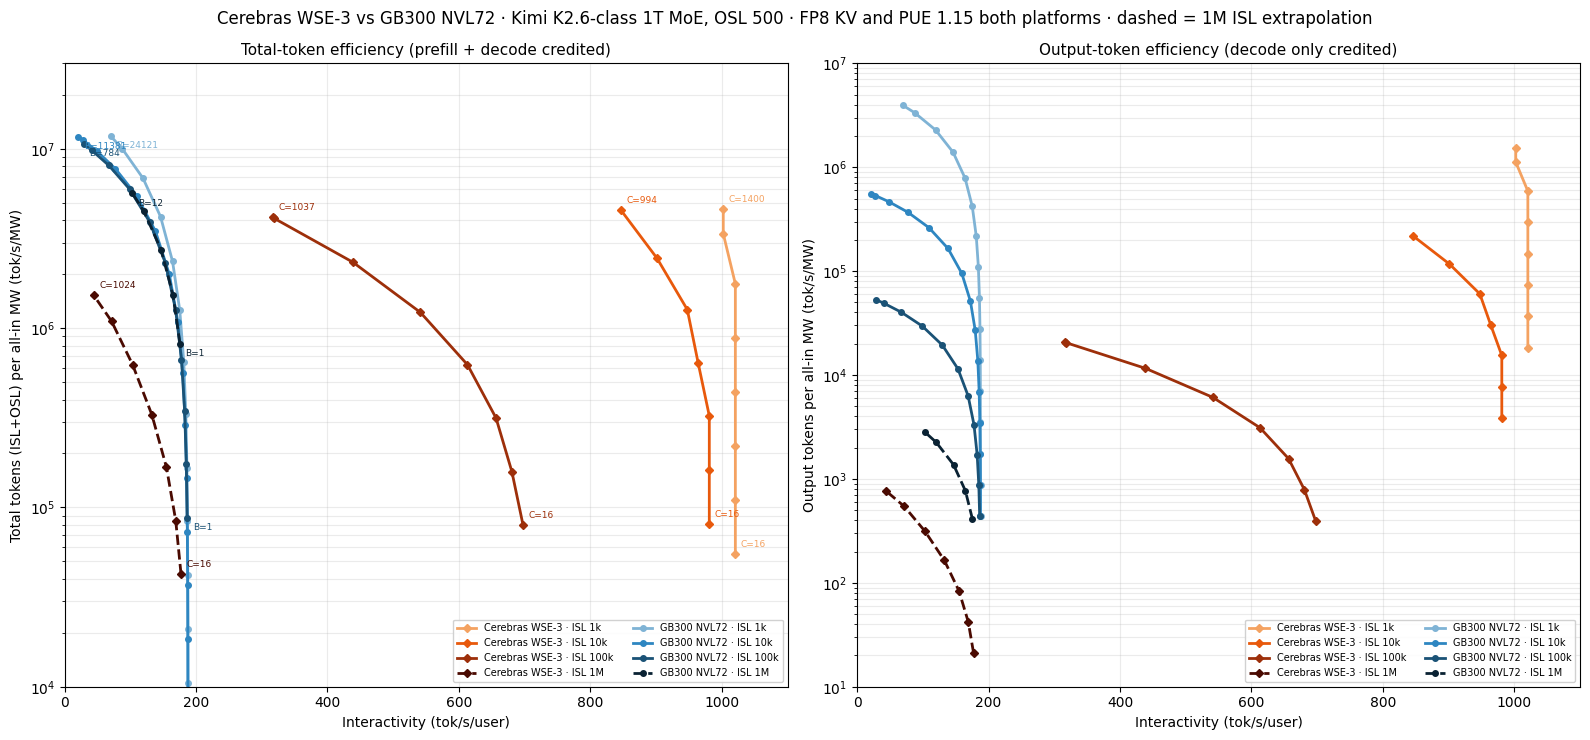

In [8]:
"""
Cerebras WSE-3 vs GB300 NVL72: Token Throughput per All-in Utility MW vs
Interactivity. Kimi K2.6-class 1T MoE (32B active), OSL = 500, one curve per
ISL (1k / 10k / 100k / 1M) per platform. Two panels: total tokens (ISL+OSL)
and output tokens only.

v3 = v2 + 1M ISL, plus generalized frontier pruning:
- Cerebras curves truncate at compute saturation (bisected) OR at the
  efficiency peak, whichever comes first: past the peak, both interactivity
  and tok/s/MW fall with C, so those deployments are Pareto-dominated
  (replicate the peak unit instead of deepening one pipeline).
- GB300 curves truncate at the first compute-capped batch (bisected):
  beyond it, throughput is flat and interactivity falls. At 1M ISL the cap
  binds almost immediately (prefill compute dominates), so BATCHES now start
  at B=1 to expose the knee.
- 1M curves drawn dashed: deepest extrapolation grade. Cerebras context tax
  (BETA = 4.4 ns/ctx-tok) is a linear fit extended 100x past its 10k anchor;
  GB300 EFF = 0.41 is calibrated at 8k-class ISL. Treat 1M as model output,
  not estimate. KV held at 35 kB/tok FP8 (35 GB/user at 1M); a K3-style
  14 kB/tok KV would shrink Cerebras 1M fleets ~2.5x.

v2 corrections retained:
1. FP8 KV (35 kB/tok) on BOTH platforms (set CB["KV_GB_PT"] = 70e-6 if CS-3
   cannot hold FP8 KV).
2. PUE 1.15 on both platforms; GB300 2.12 kW/GPU treated as IT power, EFF
   calibration point reinterpreted as IT-MW based.
3. GB300 HBM KV budget = 72 x 288 GB x 0.9 minus 500 GB FP4 weights = 18.16 TB.
4. Quadratic attention FLOPs (ATT_COEF ~ 1.4e5 FLOPs/tok/ctx-tok, MLA 576-dim
   latent x 61 layers) in both compute caps and Cerebras prefill scaling.

Unchanged calibration: Cerebras additive context-tax TPOT anchored at
measured 981 tok/s @10k ISL; T_HOP = 18 us/wafer beyond the 14-wafer
weight-only baseline; 5.6 s measured E2E @10k anchors prefill. GB300
ETA = 0.163 (max ~188 tok/s weights-read floor), EFF = 0.41; known to
understate measured TRTLLM by ~25% in the low-interactivity regime.

Provenance: GB300 8k-class curve is measurement-calibrated; 1k/100k/1M are
shape extrapolations. ALL Cerebras curves are derived from one measured
point; no multi-wafer-scale measurement exists.
"""

import math
import matplotlib.pyplot as plt

OSL, ACTIVE = 500, 32e9
PUE = 1.15
ATT_COEF = 1.4e5          # attention FLOPs per token per context token (MLA)

def flops_per_token(ISL):          # average over the request, avg ctx ~ (ISL+OSL)/2
    return 2 * ACTIVE + ATT_COEF * (ISL + OSL) / 2

def prefill_flops(L):
    return 2 * ACTIVE * L + ATT_COEF * L * L / 2

# ------------------------------ Cerebras model -------------------------------
CB = dict(PF=15.6e15, MFU=0.50, N0=14, I0_10K=981.0, T_HOP=18e-6,
          T_FIXED=0.2, KW=23 * PUE, W_GB=500.0, USE_GB=44 * 0.85,
          KV_GB_PT=35e-6,          # FP8 KV, symmetric with GB300
          BETA=4.4e-9)
CB["TPOT0"]  = 1 / CB["I0_10K"] - CB["BETA"] * 10_000
CB["T_PRE0"] = 5.6 - OSL / CB["I0_10K"] - CB["T_FIXED"]

def cerebras_point(ISL, C):
    """One operating point; returns None once compute-saturated."""
    I0 = 1.0 / (CB["TPOT0"] + CB["BETA"] * ISL)
    F  = flops_per_token(ISL) * (ISL + OSL)
    N  = math.ceil((CB["W_GB"] + C * ISL * CB["KV_GB_PT"]) / CB["USE_GB"])
    tpot    = 1 / I0 + max(0, N - CB["N0"]) * CB["T_HOP"]
    inter   = 1 / tpot
    prefill = (CB["T_PRE0"] * prefill_flops(ISL) / prefill_flops(10_000)
               * (CB["N0"] / N))
    t_req   = CB["T_FIXED"] + prefill + OSL / inter
    lam     = C / t_req
    cap     = N * CB["PF"] * CB["MFU"] / F
    if lam > cap:
        return None                                    # compute-saturated
    mw = N * CB["KW"] / 1000
    return dict(C=C, N=N, inter=inter,
                tot=lam * (ISL + OSL) / mw, out=lam * OSL / mw)

def cerebras_curve(ISL, concs):
    pts = []
    for C in concs:
        p = cerebras_point(ISL, C)
        if p is None:                                  # bisect to saturation
            lo, hi = pts[-1]["C"], C
            for _ in range(40):
                mid = 0.5 * (lo + hi)
                lo, hi = (mid, hi) if cerebras_point(ISL, mid) else (lo, mid)
            pts.append(cerebras_point(ISL, lo))
            break
        if pts and p["tot"] < pts[-1]["tot"]:
            break                                      # past peak: dominated
        pts.append(p)
    return pts

# ------------------------------ GB300 model ----------------------------------
GB = dict(BW=72 * 8e12, PF=72 * 15e15, MW=72 * 2.12e3 * PUE / 1e6,
          W=500e9, KV=35e3, ETA=0.163, MFU=0.30, EFF=0.41)
GB["KV_BUDGET"] = 72 * 288e9 * 0.9 - GB["W"]

def gb300_point(ISL, B):
    """One operating point; returns (point, capped_flag), or None if KV-bound."""
    if B * GB["KV"] * ISL > GB["KV_BUDGET"]:
        return None
    tpot   = (GB["W"] + B * GB["KV"] * ISL) / (GB["ETA"] * GB["BW"])
    total  = (B / tpot) * (ISL + OSL) / OSL
    cap    = GB["PF"] * GB["MFU"] / flops_per_token(ISL)
    capped = total > cap
    total  = min(total, cap)
    out    = total * OSL / (ISL + OSL)
    return dict(B=B, inter=out / B,
                tot=GB["EFF"] * total / GB["MW"],
                out=GB["EFF"] * out / GB["MW"]), capped

def gb300_curve(ISL, batches):
    pts = []
    for B in batches:
        r = gb300_point(ISL, B)
        if r is None:
            break                                      # KV-bound
        p, capped = r
        if capped:                                     # bisect to saturation;
            lo = pts[-1]["B"] if pts else 1e-3         # beyond it: dominated
            hi = B
            for _ in range(40):
                mid = 0.5 * (lo + hi)
                lo, hi = (mid, hi) if not gb300_point(ISL, mid)[1] else (lo, mid)
            pts.append(gb300_point(ISL, lo)[0])
            break
        pts.append(p)
    return pts

# ------------------------------ plot ----------------------------------------
ISLS = [(1_000, "1k"), (10_000, "10k"), (100_000, "100k"), (1_000_000, "1M")]
CB_COLORS = {"1k": "#f4a261", "10k": "#e8590c", "100k": "#9d2f0a",
             "1M": "#4a0a01"}
GB_COLORS = {"1k": "#7fb3d5", "10k": "#2e86c1", "100k": "#1a5276",
             "1M": "#0a2233"}
LS = {"1k": "-", "10k": "-", "100k": "-", "1M": "--"}   # dashed = extrapolation
CONCS   = [2**k for k in range(4, 15)]                   # 16 .. 16384
BATCHES = [2**k for k in range(0, 17)]                   # 1 .. 65536

plt.style.use("default")
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), facecolor="white")

for ax, key, ylab, ylim in [
        (axes[0], "tot", "Total tokens (ISL+OSL) per all-in MW (tok/s/MW)",
         (1e4, 3e7)),
        (axes[1], "out", "Output tokens per all-in MW (tok/s/MW)",
         (1e1, 1e7))]:
    ax.set_facecolor("white")
    cb_handles, gb_handles = [], []
    for ISL, tag in ISLS:
        cb = cerebras_curve(ISL, CONCS)
        ln, = ax.plot([p["inter"] for p in cb], [p[key] for p in cb],
                      marker="D", ls=LS[tag], color=CB_COLORS[tag], ms=4, lw=2,
                      label=f"Cerebras WSE-3 · ISL {tag}")
        cb_handles.append(ln)
        gb = gb300_curve(ISL, BATCHES)
        ln, = ax.plot([p["inter"] for p in gb], [p[key] for p in gb],
                      marker="o", ls=LS[tag], color=GB_COLORS[tag], ms=4, lw=2,
                      label=f"GB300 NVL72 · ISL {tag}")
        gb_handles.append(ln)
        if key == "tot":
            for p in (cb[0], cb[-1]):
                ax.annotate(f"C={p['C']:.0f}", (p["inter"], p["tot"]),
                            textcoords="offset points", xytext=(4, 5),
                            fontsize=6.5, color=CB_COLORS[tag])
            for p in (gb[0], gb[-1]):
                ax.annotate(f"B={p['B']:.0f}", (p["inter"], p["tot"]),
                            textcoords="offset points", xytext=(4, -9),
                            fontsize=6.5, color=GB_COLORS[tag])
    ax.set_xlabel("Interactivity (tok/s/user)")
    ax.set_ylabel(ylab)
    ax.set_xlim(0, 1100)
    ax.set_yscale("log")
    ax.set_ylim(*ylim)
    ax.grid(alpha=0.25, which="both")
    # ncol=2 fills column-major: column 1 = Cerebras 1k..1M, column 2 = GB300 1k..1M
    ax.legend(handles=cb_handles + gb_handles, loc="lower right",
              fontsize=7, framealpha=0.9, ncol=2)

axes[0].set_title("Total-token efficiency (prefill + decode credited)",
                  fontsize=11)
axes[1].set_title("Output-token efficiency (decode only credited)",
                  fontsize=11)
fig.suptitle("Cerebras WSE-3 vs GB300 NVL72 · Kimi K2.6-class 1T MoE, "
             "OSL 500 · FP8 KV and PUE 1.15 both platforms · "
             "dashed = 1M ISL extrapolation",
             fontsize=12)
fig.tight_layout()
fig.savefig("merged_multi_isl_v3.png", dpi=150, bbox_inches="tight")
plt.show()

Both platforms are analytical roofline models calibrated to a handful of measurements, then swept parametrically. Nothing is simulated; every curve is a closed-form equation.

GB300: decode is HBM-bandwidth-bound. TPOT = (500 GB weights + B × KV) / effective bandwidth, where effective bandwidth is 0.163 × 576 TB/s, fitted so the B→1 limit reproduces the measured ~186 tok/s max. A second fitted constant (EFF = 0.41) scales the result through a measured vLLM tok/s/MW point. The sweep variable is batch size B, bounded by HBM capacity and an FP4 compute cap. The 8k-class curve passes through real InferenceX data; the 1k/100k/1M curves are the same equation with a different KV term, so they inherit the shape but not the validation.

Cerebras: decode runs from SRAM, so there is no batch knob. Instead TPOT = base + 4.4 ns per context token (linear tax, anchored at the one measured point, 981 tok/s at 10k ISL) + 18 µs per pipeline wafer beyond the 14 that hold weights. Fleet size N is whatever it takes to fit 500 GB weights plus all users' KV into 37.4 GB usable SRAM per wafer, so the sweep variable is concurrency C, and each C implies a pipeline depth. Prefill is anchored to a measured 5.6 s end-to-end at 10k and scaled by FLOPs. The entire family derives from that single anchor.

Both sides then get identical treatment: throughput ÷ all-in MW (PUE 1.15), quadratic attention FLOPs in the compute caps, and truncation of dominated points. "1M" means these equations pushed 100x past their calibration range, hence dashed.